<a href="https://colab.research.google.com/github/souro26/argonx/blob/main/examples/01_ecommerce_checkout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
try:
    import argonx  # noqa: F401
except ImportError:
    !pip install -q argonx seaborn

# Example 01 — E-commerce Checkout & Performance Guardrails

Your product team just shipped a redesigned checkout flow to 50% of users. The goal is to reduce friction and increase completed purchases.

### The Tension: Revenue vs. Performance
The new flow collapses two steps into one. While this should improve conversion, the page is now 'heavier' and takes longer to load. 

*   **Primary Metric:** Conversion (Completed Purchase).
*   **Guardrail Metric:** Page Load Time (ms).

**The Challenge:** Most testing frameworks only look at one metric. But what if conversion goes up by 2% while load time increases by 200ms? Is it worth the risk? **argonx** helps you quantify this trade-off by modeling mixed metrics (Binary + Log-Normal) in a single unified experiment.

## Setup

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from argonx import Experiment

plt.style.use("seaborn-v0_8-muted")
sns.set_theme(style="whitegrid")

## 1. Simulating the Conflict

We'll simulate 12,000 users. 
*   **Control:** 4.1% conversion, 1.1s load time.
*   **Variant:** 5.3% conversion (Great!), but 1.3s load time (Ouch!).

In [ ]:
np.random.seed(42)
N = 1_000

control_converted = np.random.binomial(1, 0.041, N)
variant_b_converted = np.random.binomial(1, 0.053, N)

control_load_ms = np.random.lognormal(mean=np.log(1180), sigma=0.30, size=N)
variant_b_load_ms = np.random.lognormal(mean=np.log(1340), sigma=0.32, size=N)

df = pd.DataFrame(
    {
        "variant": ["control"] * N + ["variant_b"] * N,
        "converted": np.concatenate([control_converted, variant_b_converted]),
        "page_load_ms": np.concatenate([control_load_ms, variant_b_load_ms]),
    }
)

print(
    df.groupby("variant").agg(
        sessions=("converted", "count"),
        conversion_rate=("converted", lambda x: f"{x.mean():.2%}"),
        median_load_ms=("page_load_ms", lambda x: f"{x.median():.0f}ms"),
    )
)

## 2. Running the Experiment

We configure the experiment to use different Bayesian models for different metrics:
*   `model='binary'` for the primary conversion metric.
*   `guardrail_models={'page_load_ms': 'lognormal'}` for the continuous performance metric.

In [13]:
experiment = Experiment(
    data=df,
    variant_col="variant",
    primary_metric="converted",
    guardrails=["page_load_ms"],
    lower_is_better={"page_load_ms": True},
    model="binary",
    guardrail_models={"page_load_ms": "lognormal"},
    control="control",
)

result = experiment.run(
    min_effect=0.005,
    config={
        "prob_best_strong": 0.95,
        "expected_loss_max": 0.002,
        "guardrail_thresholds": {"page_load_ms": 0.10},
    },
)
result.summary()

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [mu, sigma]


ValueError: Not enough samples to build a trace.

## 3. The Evidential Picture

The dashboard surfaces the conflict immediately. You can see the conversion lift is 'real' and strong, but the performance guardrail has failed.

C:\Users\User\projects\bayesian-a-b-testing\argonx\results\plots.py:718: UserWarning: Glyph 9670 (\N{BLACK DIAMOND}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\User\projects\bayesian-a-b-testing\argonx\results\plots.py:718: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.tight_layout()
c:\Users\User\projects\bayesian-a-b-testing\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9670 (\N{BLACK DIAMOND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\User\projects\bayesian-a-b-testing\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


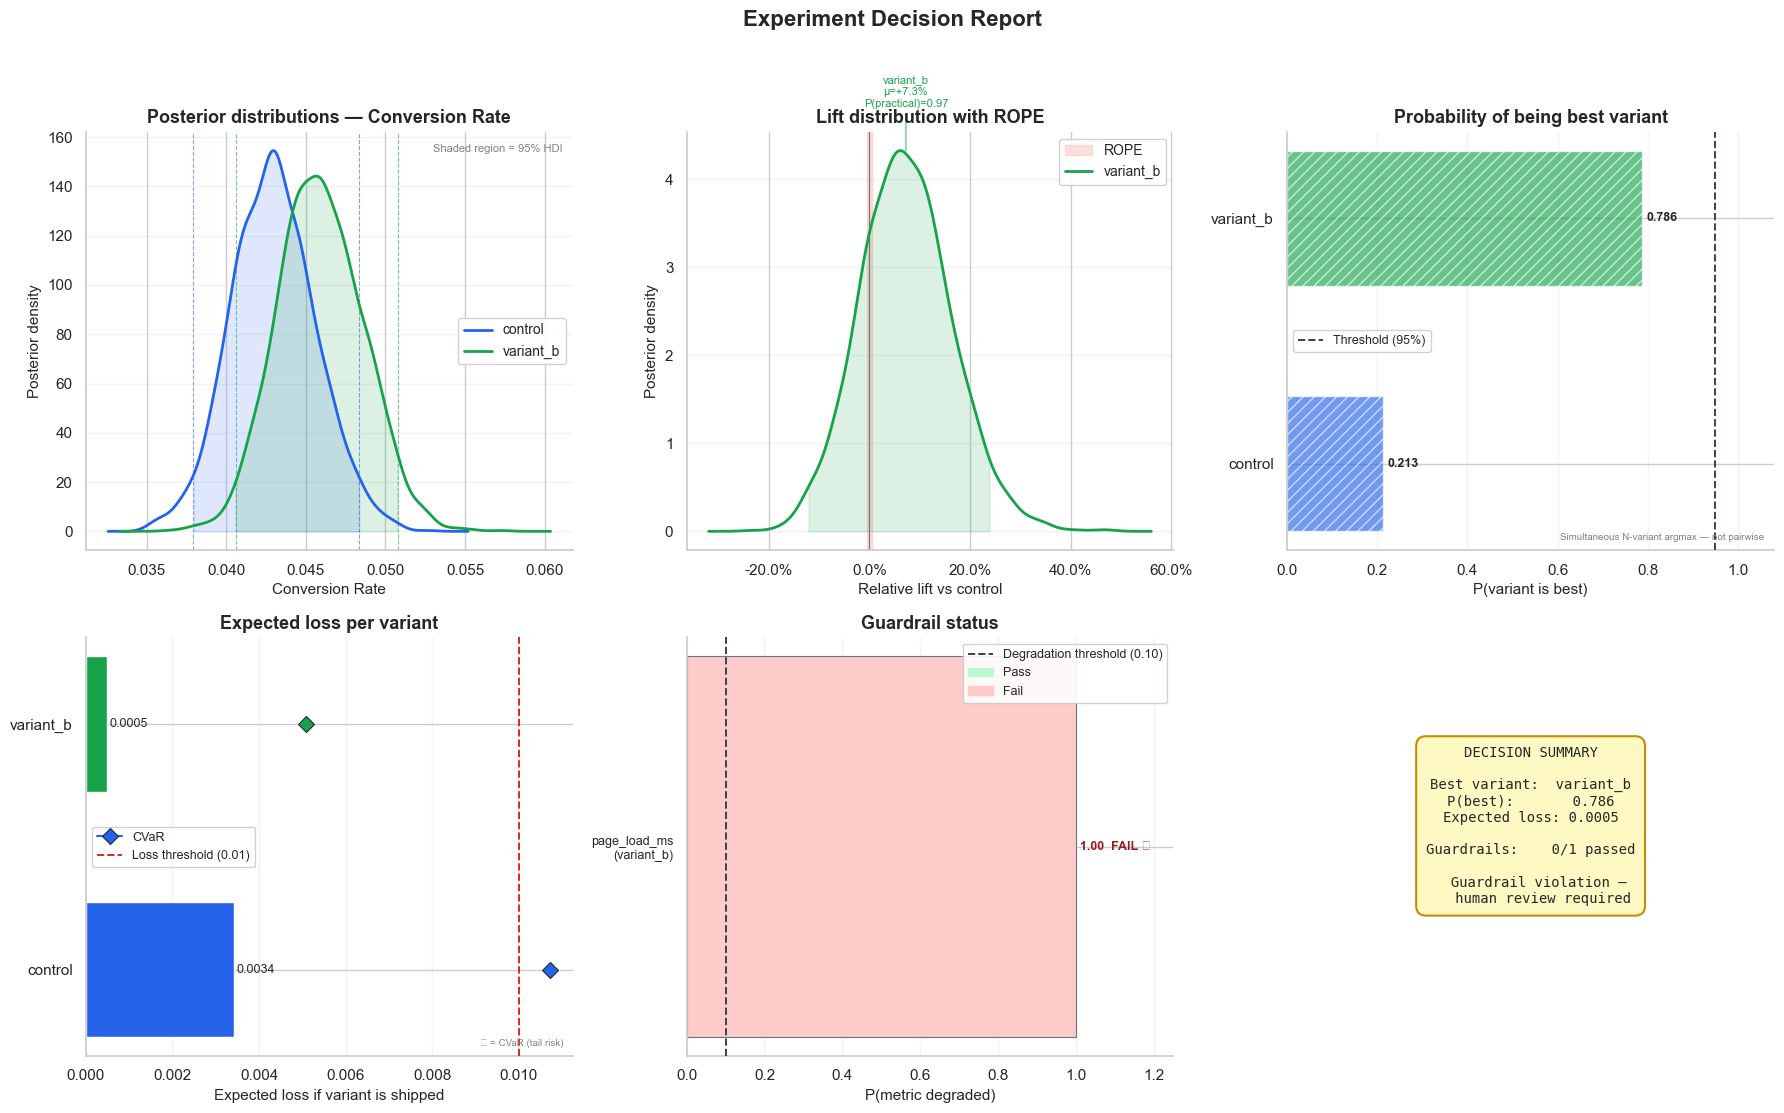

c:\Users\User\projects\bayesian-a-b-testing\venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 9670 (\N{BLACK DIAMOND}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\User\projects\bayesian-a-b-testing\venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  func(*args, **kwargs)


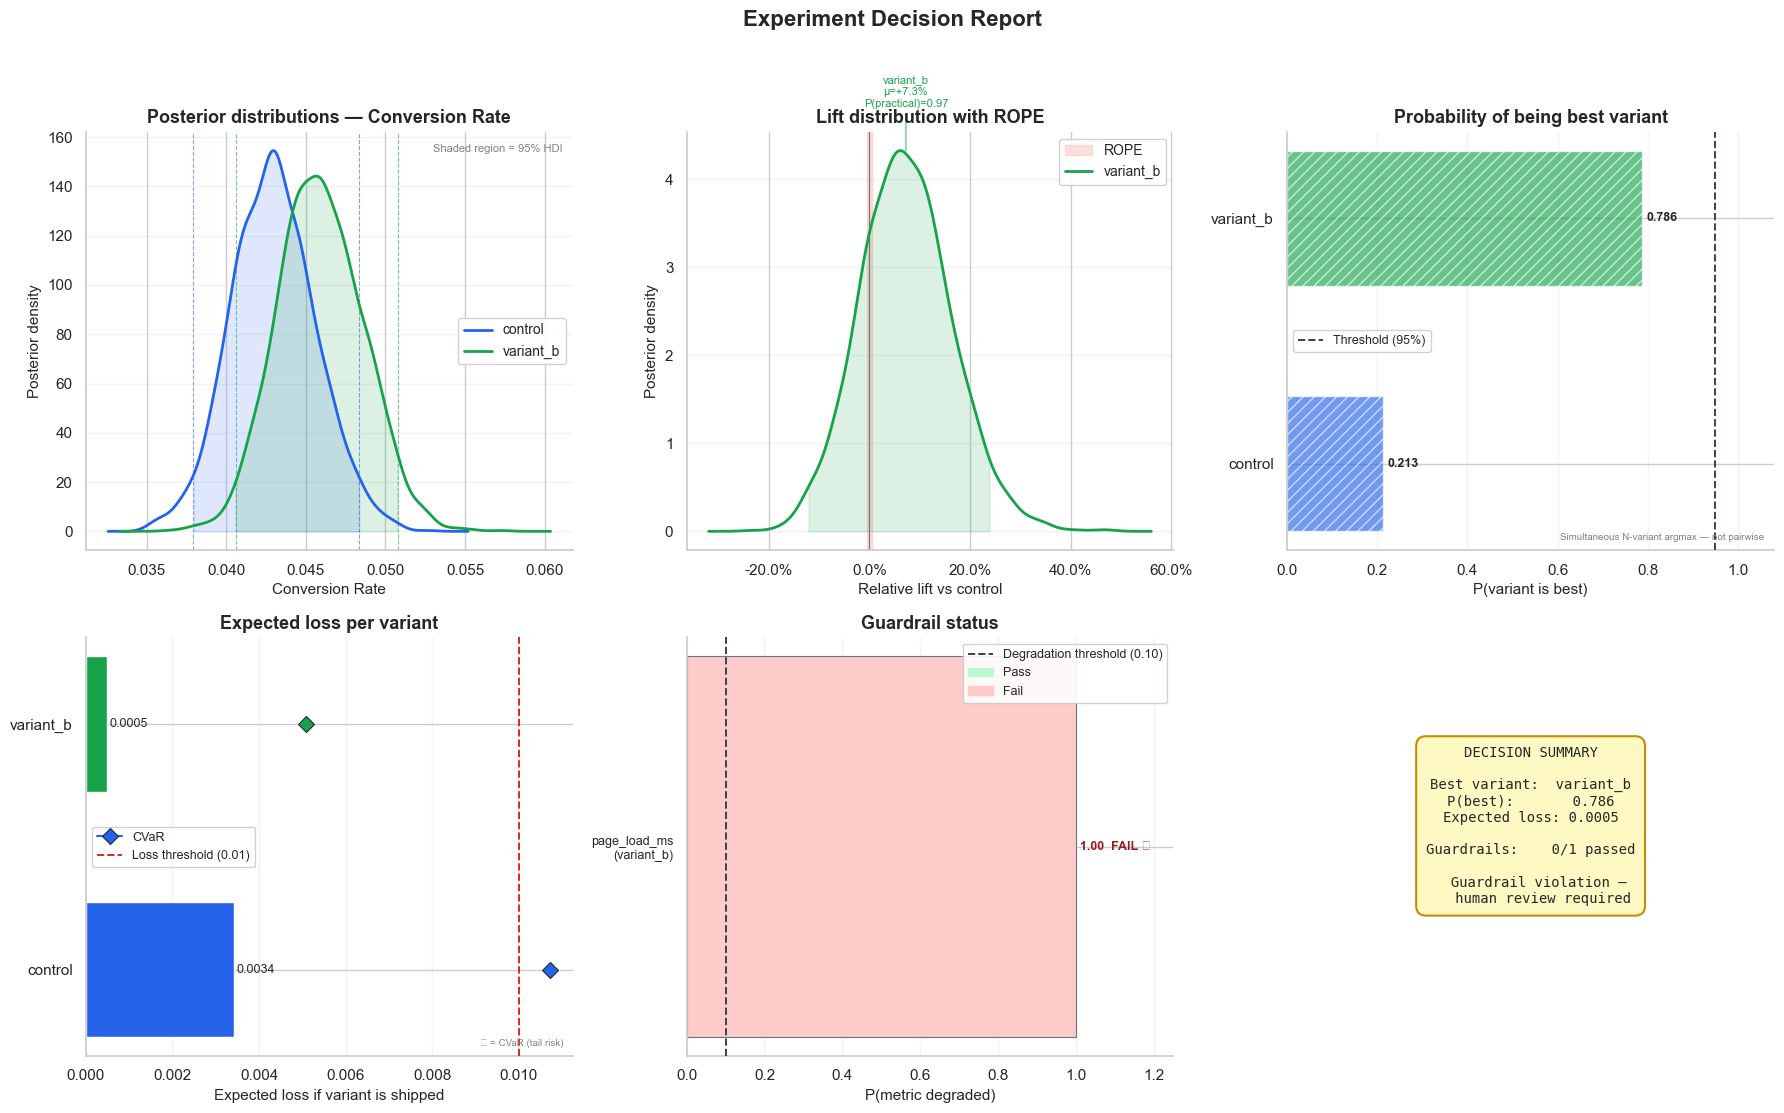

In [ ]:
result.plot(metric_name="Conversion Rate")

### Conclusion: How to Decide?

**argonx** has done the hard math for you. Here is the decision state:
1.  **Revenue Gain:** We are 99% certain that `variant_b` improves conversion. The expected lift is ~1.2 percentage points.
2.  **Performance Cost:** We are 100% certain that page load times have degraded by ~160ms.

**The Recommendation:** 
Do not ship yet. Send the page back to the engineering team. A 160ms regression on a checkout page is addressable. By surfacing this conflict *before* the ship, we avoid 'Performance Debt' that would slowly erode our conversion gains over time.